 Iris Flower Classification

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Load Dataset

In [2]:
df = pd.read_csv("Iris.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Basic Information

In [3]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSpecies Count:")
print(df["Species"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Species Count:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Visualization

Species Distribution

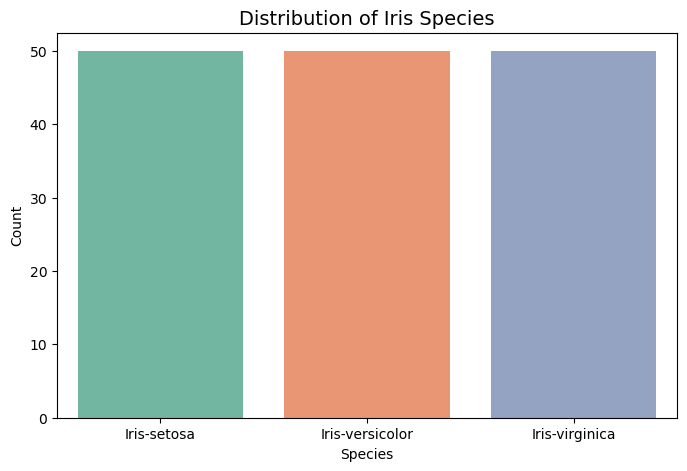

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Species',
    data=df,
    hue='Species',
    palette='Set2',
    legend=False
)

plt.title("Distribution of Iris Species", fontsize=14)
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

Pairplot

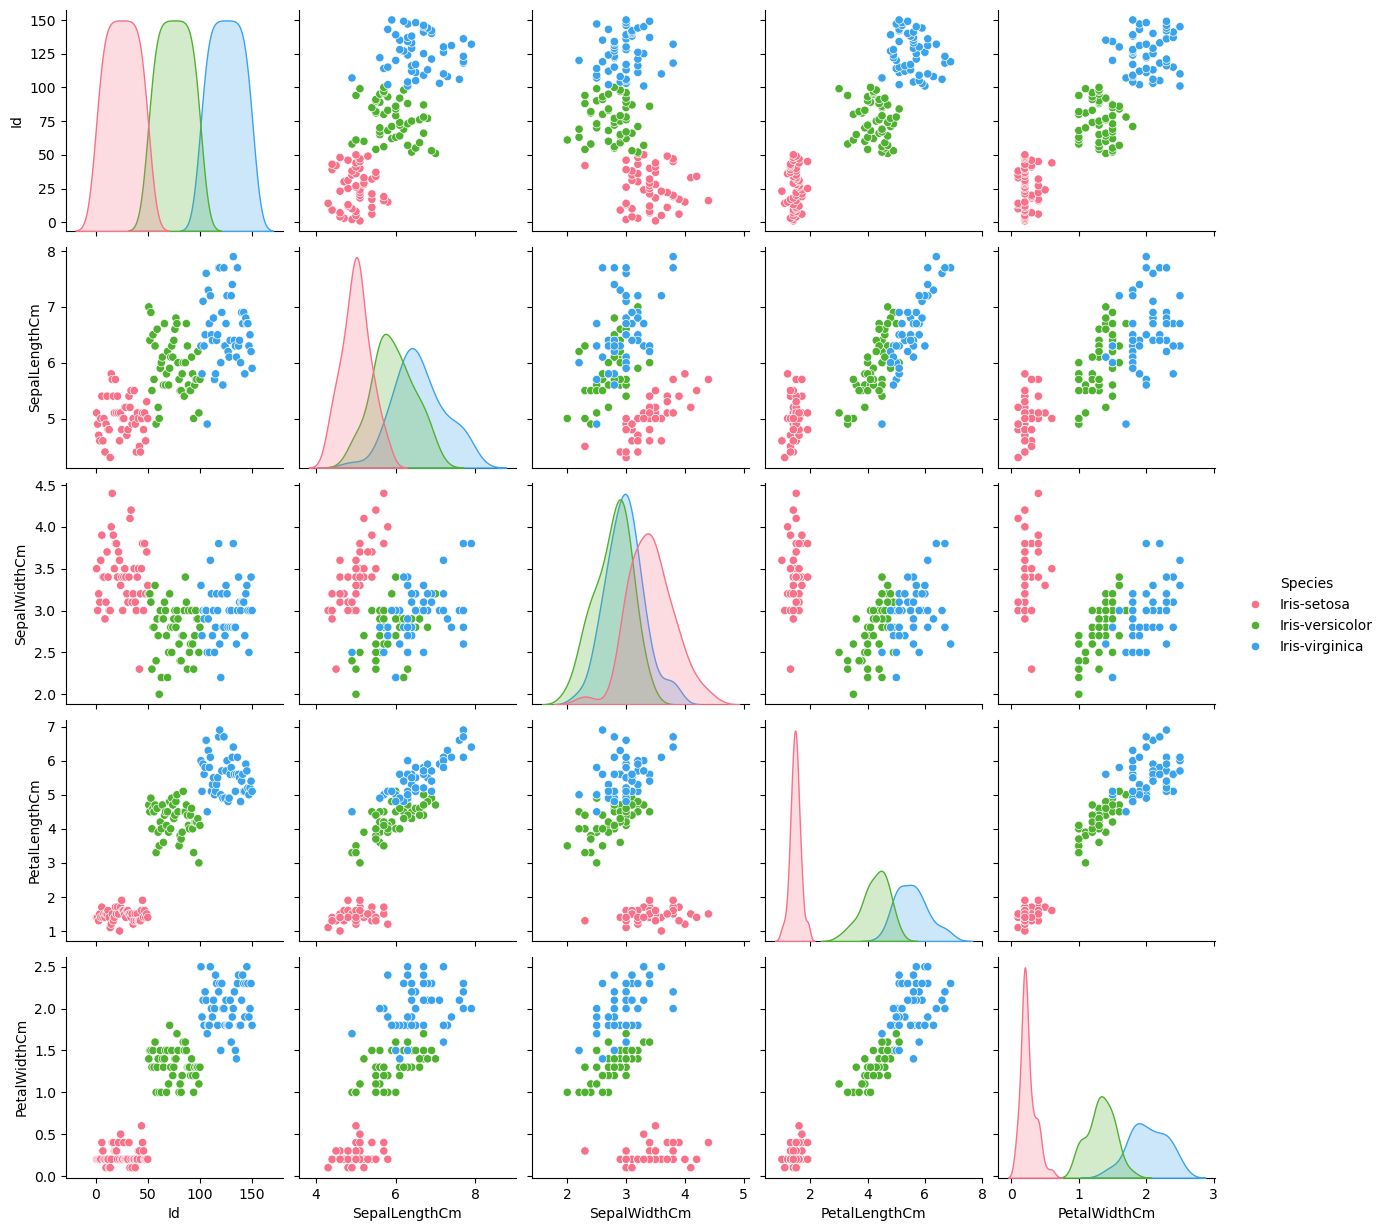

In [5]:
sns.pairplot(
    df,
    hue="Species",
    palette="husl"
)

plt.show()

Correlation Heatmap

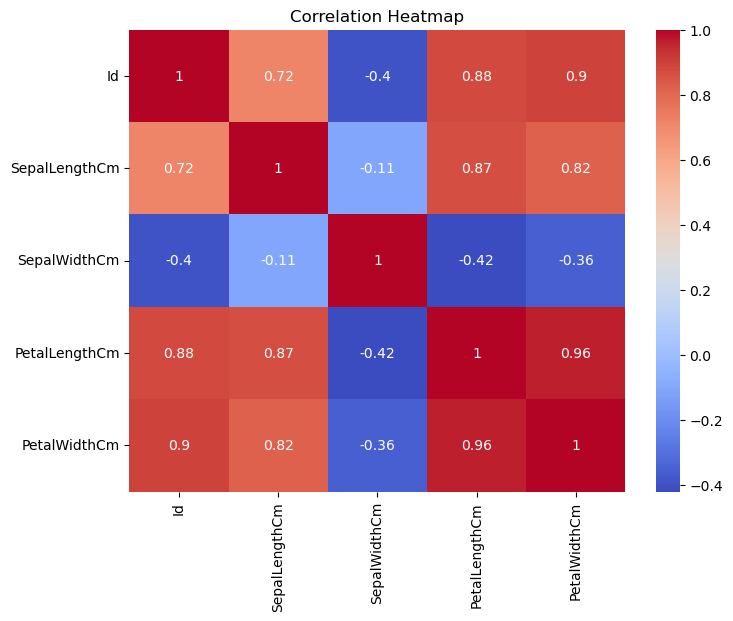

In [6]:
plt.figure(figsize=(8,6))

numeric_df = df.drop("Species", axis=1)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Prepare Data

In [7]:
X = df.drop("Species", axis=1)
y = df["Species"]

Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [10]:
y_pred = model.predict(X_test)

Accuracy

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", round(accuracy*100,2), "%")

Accuracy Score: 100.0 %


Classification Report

In [12]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

